In [1]:
import pandas as pd

from src.real_world.preprocess_real import prepare_real_dataset
from src.real_world.train_lr_real import train_lr_real, evaluate_lr_real
from src.real_world.train_mlp_real import train_mlp_real

from src.metrics.evaluation import evaluate_model
from src.metrics.visualize_fairness import plot_equal_opportunity, plot_eo_comparison


In [2]:
def extract_metric_dict(group_metrics, metric_name):
    """
    group_metrics = results["gender_metrics"] or results["race_metrics"]
    metric_name = "TPR" | "FNR" | "Precision" | "Calibration"
    Returns {group: metric_value}
    """
    return {g: m[metric_name] for g, m in group_metrics.items()}


In [3]:
df = pd.read_csv("diabetes_dataset.csv")
data = prepare_real_dataset(df)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
sens_test = data["sens_test"]

X_train.shape, X_test.shape


((69987, 12), (29995, 12))

In [5]:
lr_model = train_lr_real(X_train, y_train)
lr_results = evaluate_lr_real(lr_model, X_test, y_test)

y_pred_lr = lr_results["y_pred"]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]   # REQUIRED for calibration

print("LR Accuracy:", lr_results["accuracy"])


LR Accuracy: 0.9606934489081513


In [6]:
fair_lr = evaluate_model(
    y_test.values,
    y_pred_lr,
    y_prob_lr,
    sens_test
)

print("LR Gender EO Gap:", fair_lr["gender_gap"])
print("LR Race EO Gap:", fair_lr["race_gap"])


LR Gender EO Gap: 0.001582308668971355
LR Race EO Gap: 0.02537127405623507


Epoch 1/20 | Train Loss 0.1307, Acc 0.9557 | Val Loss 0.1112, Acc 0.9624
Epoch 2/20 | Train Loss 0.1016, Acc 0.9644 | Val Loss 0.1008, Acc 0.9663
Epoch 3/20 | Train Loss 0.0916, Acc 0.9683 | Val Loss 0.0912, Acc 0.9693
Epoch 4/20 | Train Loss 0.0866, Acc 0.9696 | Val Loss 0.0878, Acc 0.9704
Epoch 5/20 | Train Loss 0.0845, Acc 0.9708 | Val Loss 0.0859, Acc 0.9710
Epoch 6/20 | Train Loss 0.0835, Acc 0.9714 | Val Loss 0.0859, Acc 0.9709
Epoch 7/20 | Train Loss 0.0825, Acc 0.9712 | Val Loss 0.0872, Acc 0.9707
Epoch 8/20 | Train Loss 0.0822, Acc 0.9718 | Val Loss 0.0860, Acc 0.9714
Epoch 9/20 | Train Loss 0.0816, Acc 0.9718 | Val Loss 0.0852, Acc 0.9711
Epoch 10/20 | Train Loss 0.0814, Acc 0.9720 | Val Loss 0.0864, Acc 0.9715
Epoch 11/20 | Train Loss 0.0816, Acc 0.9719 | Val Loss 0.0840, Acc 0.9716
Epoch 12/20 | Train Loss 0.0810, Acc 0.9722 | Val Loss 0.0841, Acc 0.9715
Epoch 13/20 | Train Loss 0.0807, Acc 0.9720 | Val Loss 0.0870, Acc 0.9714
Epoch 14/20 | Train Loss 0.0805, Acc 0.9722 | V

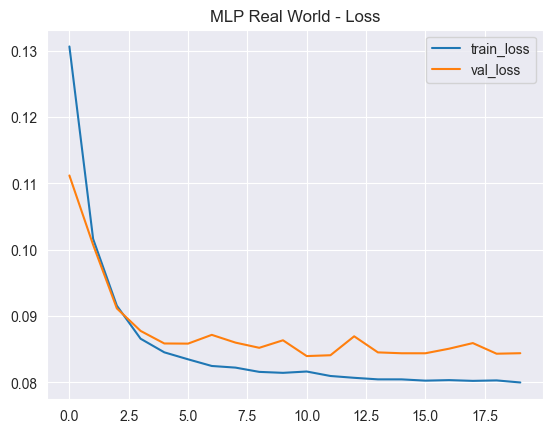

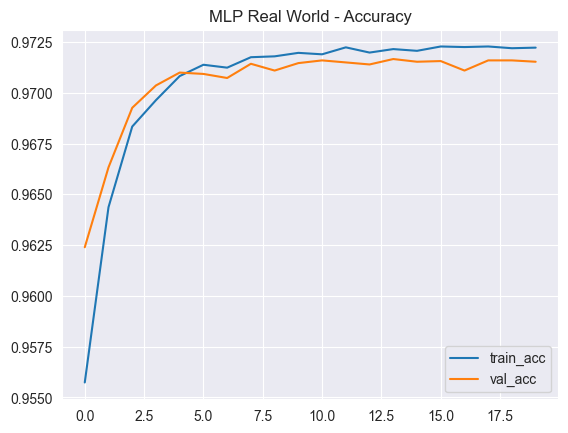

NN Accuracy: 0.9715285880980163


In [7]:
nn_out = train_mlp_real(
    X_train, y_train,
    X_test, y_test,
    input_dim=X_train.shape[1],
    n_epochs=20,
    lr=0.001
)

y_pred_nn = nn_out["y_pred"]
y_prob_nn = nn_out["probs"]    # needed for calibration

print("NN Accuracy:", nn_out["accuracy"])


In [9]:
import matplotlib.pyplot as plt

def add_value_labels(bars, offset=0.01):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

def plot_metric(metric_dict, title, ylabel, color="skyblue"):
    groups = list(metric_dict.keys())
    values = list(metric_dict.values())

    plt.figure(figsize=(6,4))
    bars = plt.bar(groups, values, color=color)
    add_value_labels(bars)

    plt.ylim(0, max(values) + 0.1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.show()

def plot_equal_opportunity(tpr_dict, title="Equal Opportunity"):
    values = list(tpr_dict.values())
    eo_gap = max(values) - min(values)

    plot_metric(
        tpr_dict,
        f"{title} (EO Gap = {eo_gap:.3f})",
        ylabel="TPR (Recall)",
        color="lightblue"
    )


LR plots


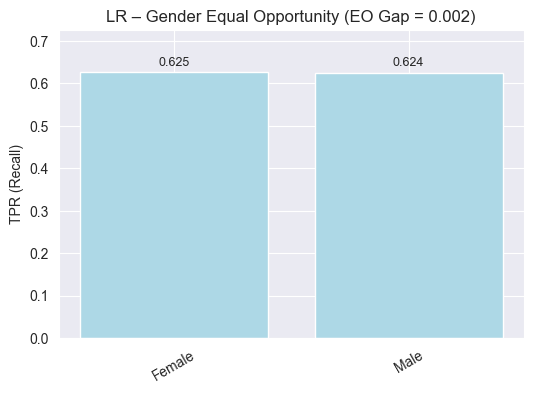

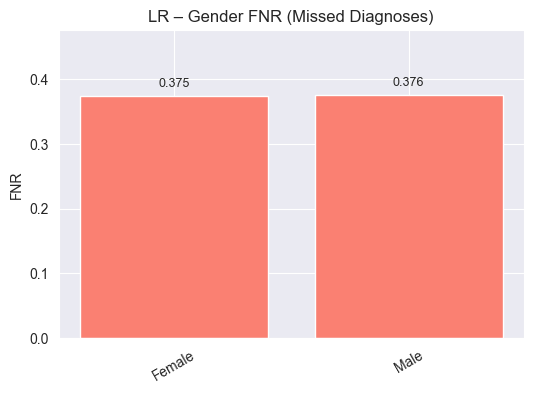

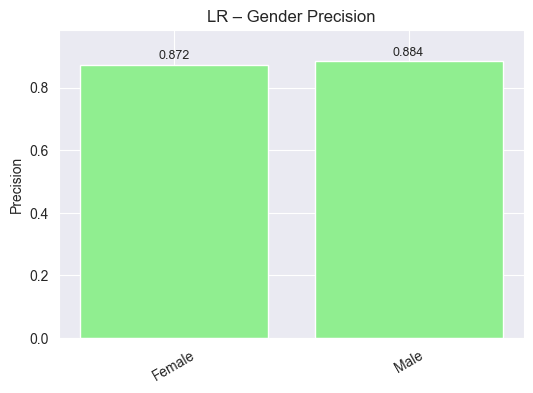

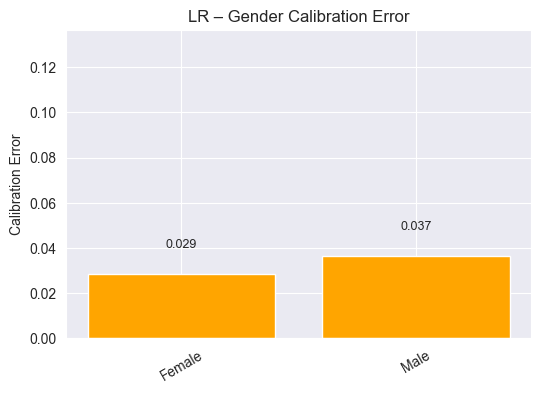

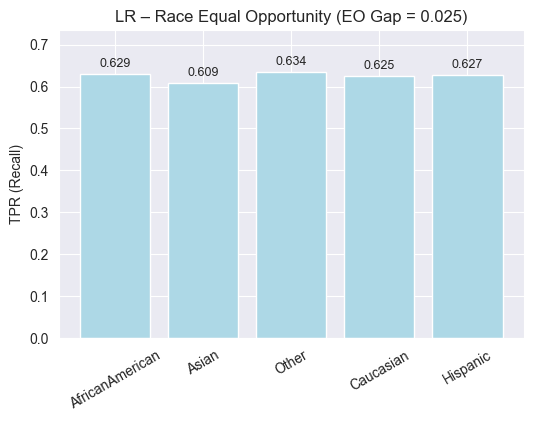

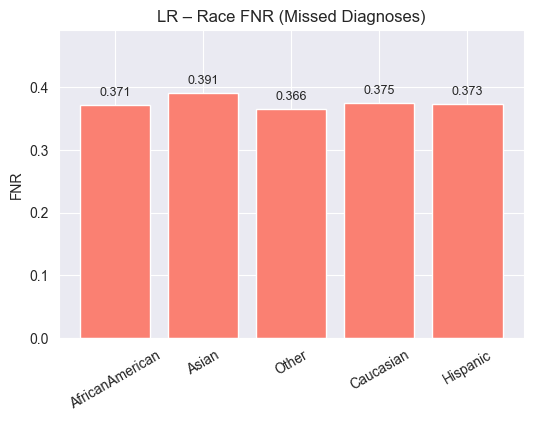

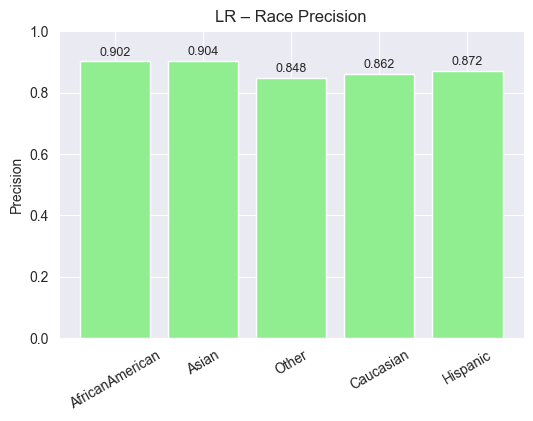

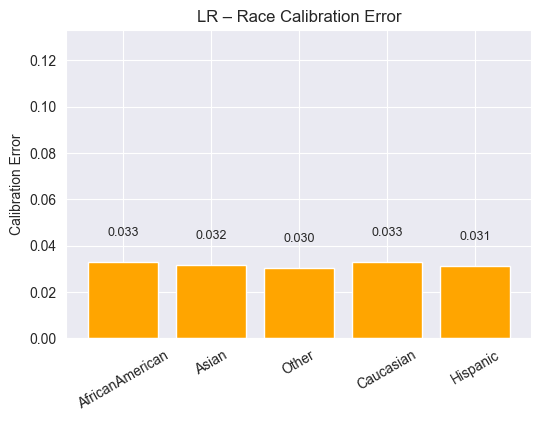

NN plots


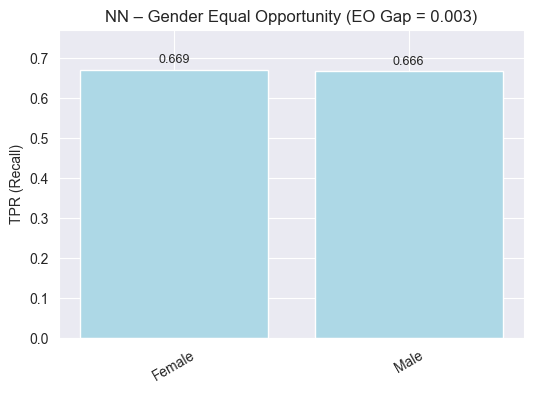

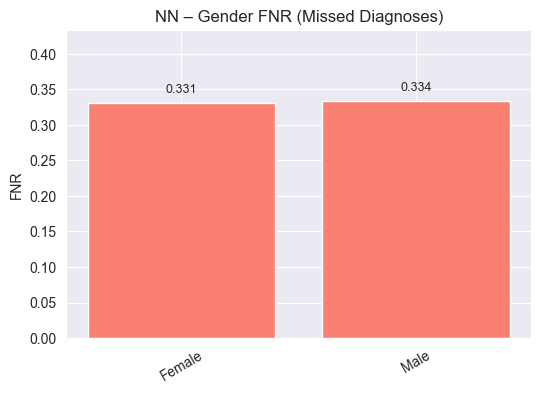

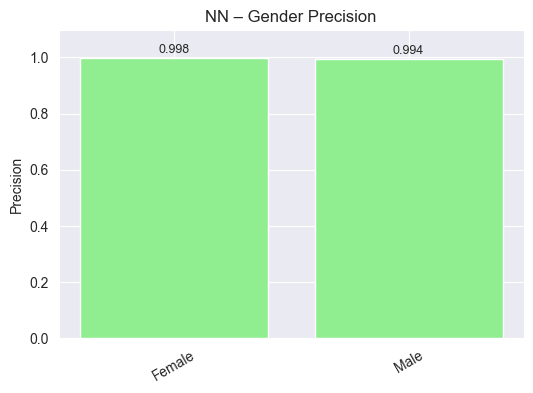

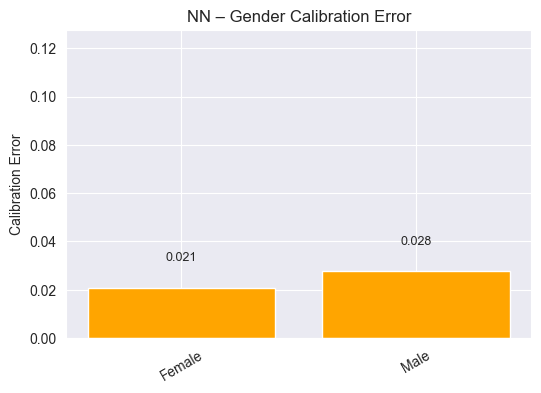

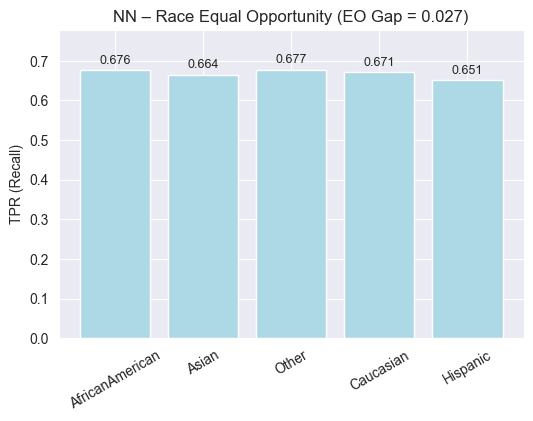

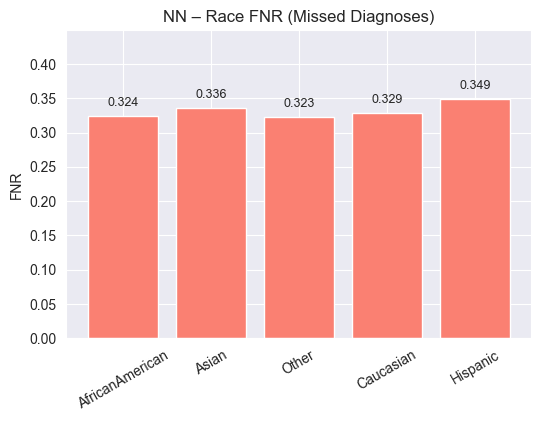

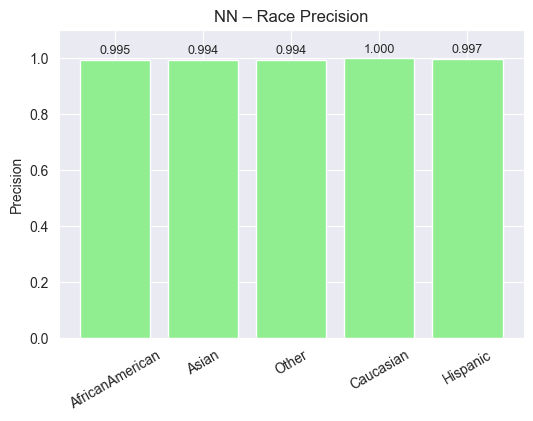

In [11]:

print("LR plots")

# Gender
plot_equal_opportunity(
    extract_metric_dict(fair_lr["gender_metrics"], "TPR"),
    "LR – Gender Equal Opportunity"
)
plot_metric(
    extract_metric_dict(fair_lr["gender_metrics"], "FNR"),
    "LR – Gender FNR (Missed Diagnoses)",
    ylabel="FNR",
    color="salmon"
)
plot_metric(
    extract_metric_dict(fair_lr["gender_metrics"], "Precision"),
    "LR – Gender Precision",
    ylabel="Precision",
    color="lightgreen"
)
plot_metric(
    extract_metric_dict(fair_lr["gender_metrics"], "Calibration"),
    "LR – Gender Calibration Error",
    ylabel="Calibration Error",
    color="orange"
)

# Race
plot_equal_opportunity(
    extract_metric_dict(fair_lr["race_metrics"], "TPR"),
    "LR – Race Equal Opportunity"
)
plot_metric(
    extract_metric_dict(fair_lr["race_metrics"], "FNR"),
    "LR – Race FNR (Missed Diagnoses)",
    ylabel="FNR",
    color="salmon"
)
plot_metric(
    extract_metric_dict(fair_lr["race_metrics"], "Precision"),
    "LR – Race Precision",
    ylabel="Precision",
    color="lightgreen"
)
plot_metric(
    extract_metric_dict(fair_lr["race_metrics"], "Calibration"),
    "LR – Race Calibration Error",
    ylabel="Calibration Error",
    color="orange"
)

print("NN plots")

# Gender
plot_equal_opportunity(
    extract_metric_dict(fair_nn["gender_metrics"], "TPR"),
    "NN – Gender Equal Opportunity"
)
plot_metric(
    extract_metric_dict(fair_nn["gender_metrics"], "FNR"),
    "NN – Gender FNR (Missed Diagnoses)",
    ylabel="FNR",
    color="salmon"
)
plot_metric(
    extract_metric_dict(fair_nn["gender_metrics"], "Precision"),
    "NN – Gender Precision",
    ylabel="Precision",
    color="lightgreen"
)

# Race
plot_equal_opportunity(
    extract_metric_dict(fair_nn["race_metrics"], "TPR"),
    "NN – Race Equal Opportunity"
)
plot_metric(
    extract_metric_dict(fair_nn["race_metrics"], "FNR"),
    "NN – Race FNR (Missed Diagnoses)",
    ylabel="FNR",
    color="salmon"
)
plot_metric(
    extract_metric_dict(fair_nn["race_metrics"], "Precision"),
    "NN – Race Precision",
    ylabel="Precision",
    color="lightgreen"
)



NameError: name 'fair_lr_results' is not defined